In [1]:
!pip install virtualenv --quiet
!virtualenv venv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 42.2 MB/s eta 0:00:00
created virtual environment CPython3.10.12.final.0-64 in 598ms
  creator CPython3Posix(dest=/content/venv, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, setuptools=bundle, wheel=bundle, via=copy, app_data_dir=/root/.local/share/virtualenv)
    added seed packages: pip==24.3.1, setuptools==75.2.0, wheel==0.44.0
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator


In [2]:
!source venv/bin/activate


In [4]:
!pip install datasets

  Using cached datasets-3.1.0-py3-none-any.whl.metadata (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [5]:
# Install necessary libraries
!pip install datasets transformers librosa soundfile torch numpy sklearn --quiet

import os
import librosa
import soundfile as sf
import torch
import numpy as np
from datasets import Dataset, DatasetDict, Audio
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from torch.utils.data import DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [6]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [9]:
!unzip /content/drive/MyDrive/RAVDESS.zip -d /content/

Archive:  /content/drive/MyDrive/RAVDESS.zip
  inflating: /content/Actor_01/03-01-01-01-01-01-01.wav  
  inflating: /content/Actor_01/03-01-01-01-01-02-01.wav  
  inflating: /content/Actor_01/03-01-01-01-02-01-01.wav  
  inflating: /content/Actor_01/03-01-01-01-02-02-01.wav  
  inflating: /content/Actor_01/03-01-02-01-01-01-01.wav  
  inflating: /content/Actor_01/03-01-02-01-01-02-01.wav  
  inflating: /content/Actor_01/03-01-02-01-02-01-01.wav  
  inflating: /content/Actor_01/03-01-02-01-02-02-01.wav  
  inflating: /content/Actor_01/03-01-02-02-01-01-01.wav  
  inflating: /content/Actor_01/03-01-02-02-01-02-01.wav  
  inflating: /content/Actor_01/03-01-02-02-02-01-01.wav  
  inflating: /content/Actor_01/03-01-02-02-02-02-01.wav  
  inflating: /content/Actor_01/03-01-03-01-01-01-01.wav  
  inflating: /content/Actor_01/03-01-03-01-01-02-01.wav  
  inflating: /content/Actor_01/03-01-03-01-02-01-01.wav  
  inflating: /content/Actor_01/03-01-03-01-02-02-01.wav  
  inflating: /content/Actor

In [7]:
DATASET_PATH = "/content/audio_speech_actors_01-24"

In [11]:
import pandas as pd

def prepare_metadata(dataset_path):
    metadata = []
    labels = {
        "01": "neutral",
        "02": "calm",
        "03": "happy",
        "04": "sad",
        "05": "angry",
        "06": "fearful",
        "07": "disgust",
        "08": "surprised"
    }
    for actor_folder in os.listdir(dataset_path):
        actor_path = os.path.join(dataset_path, actor_folder)
        if os.path.isdir(actor_path):
            for file_name in os.listdir(actor_path):
                if file_name.endswith(".wav"):
                    emotion_code = file_name.split("-")[2]
                    emotion = labels.get(emotion_code, "unknown")
                    file_path = os.path.join(actor_path, file_name)
                    metadata.append({"path": file_path, "emotion": emotion})
    return pd.DataFrame(metadata)

# Prepare metadata
metadata = prepare_metadata(DATASET_PATH)

# Encode labels
le = LabelEncoder()
metadata["label"] = le.fit_transform(metadata["emotion"])

# Split into train, validation, and test sets
train_val_data, test_data = train_test_split(metadata, test_size=0.2, random_state=42, stratify=metadata["label"])
train_data, val_data = train_test_split(train_val_data, test_size=0.2, random_state=42, stratify=train_val_data["label"])

In [12]:
def create_dataset(data):
    return Dataset.from_dict({
        "path": data["path"].tolist(),
        "label": data["label"].tolist(),
    })

train_dataset = create_dataset(train_data)
val_dataset = create_dataset(val_data)
test_dataset = create_dataset(test_data)

# Combine into DatasetDict
dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
})

In [39]:
def augment_noise(audio, sr):
    noise = np.random.normal(0, 0.002, len(audio))
    return audio + noise

def augment_pitch_shift(audio, sr, n_steps=2):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)

In [ ]:
from transformers import AutoProcessor, AutoModelForPreTraining

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=len(le.classes_),  # Number of emotion labels
    gradient_checkpointing=True
)



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [40]:
def preprocess_function(batch):
    audio_array, sampling_rate = librosa.load(batch["path"], sr=16000)

    augmentations = [
        lambda x: augment_noise(x, sr=sampling_rate),
        lambda x: augment_pitch_shift(x, sr=sampling_rate, n_steps=np.random.randint(-2, 3))
    ]

    if np.random.rand() > 0.5:  # 50% probability to augment
        augmentation = np.random.choice(augmentations)
        audio_array = augmentation(audio_array)

    audio_array = librosa.util.normalize(audio_array) #normalize

    inputs = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt", padding=True)
    batch["input_values"] = inputs.input_values[0].numpy()
    return batch

dataset_dict = dataset_dict.map(preprocess_function, remove_columns=["path"])


Map:   0%|          | 0/921 [00:00<?, ? examples/s]

Map:   0%|          | 0/231 [00:00<?, ? examples/s]

Map:   0%|          | 0/288 [00:00<?, ? examples/s]

In [41]:
def collate_fn(batch):
    # Extract input values and labels
    input_values = [x["input_values"] for x in batch]
    labels = [x["label"] for x in batch]

    # Pad input values using the processor
    inputs = processor.pad(
        {"input_values": input_values},
        padding=True,
        return_tensors="pt"
    )

    # Convert labels to a tensor
    labels = torch.tensor(labels)

    return {"input_values": inputs.input_values, "labels": labels}


train_loader = DataLoader(dataset_dict["train"], batch_size=8, collate_fn=collate_fn, shuffle=True)
val_loader = DataLoader(dataset_dict["validation"], batch_size=8, collate_fn=collate_fn)
test_loader = DataLoader(dataset_dict["test"], batch_size=8, collate_fn=collate_fn)


In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=len(le.classes_),
    gradient_checkpointing=True
)
# Freeze all parameters
for param in model.wav2vec2.encoder.parameters():
    param.requires_grad = False

n = 6  # Number of layers to unfreeze
for param in list(model.wav2vec2.encoder.layers[-n:].parameters()):
    param.requires_grad = True

for param in model.wav2vec2.feature_extractor.parameters():
    param.requires_grad = False

model.config.hidden_dropout = 0.4
model.config.attention_dropout = 0.4
model.to(device)
optimizer = AdamW([
    {"params": model.wav2vec2.encoder.parameters(), "lr": 1e-5, "weight_decay": 0.01},
    {"params": model.classifier.parameters(), "lr": 1e-4, "weight_decay": 0.05}
])


scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3, verbose=True)

loss_fn = CrossEntropyLoss()
early_stopping_patience = 5

# Training loop with early stopping
best_val_loss = float("inf")
patience_counter = 0
num_epochs = 40

/usr/local/lib/python3.10/dist-packages/transformers/configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [51]:
# Print trainable parameter names to verify
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"Trainable: {name}")


Trainable: wav2vec2.masked_spec_embed
Trainable: wav2vec2.feature_projection.layer_norm.weight
Trainable: wav2vec2.feature_projection.layer_norm.bias
Trainable: wav2vec2.feature_projection.projection.weight
Trainable: wav2vec2.feature_projection.projection.bias
Trainable: wav2vec2.encoder.layers.10.attention.k_proj.weight
Trainable: wav2vec2.encoder.layers.10.attention.k_proj.bias
Trainable: wav2vec2.encoder.layers.10.attention.v_proj.weight
Trainable: wav2vec2.encoder.layers.10.attention.v_proj.bias
Trainable: wav2vec2.encoder.layers.10.attention.q_proj.weight
Trainable: wav2vec2.encoder.layers.10.attention.q_proj.bias
Trainable: wav2vec2.encoder.layers.10.attention.out_proj.weight
Trainable: wav2vec2.encoder.layers.10.attention.out_proj.bias
Trainable: wav2vec2.encoder.layers.10.layer_norm.weight
Trainable: wav2vec2.encoder.layers.10.layer_norm.bias
Trainable: wav2vec2.encoder.layers.10.feed_forward.intermediate_dense.weight
Trainable: wav2vec2.encoder.layers.10.feed_forward.intermed

In [45]:
from sklearn.metrics import accuracy_score

def compute_accuracy(preds, labels):
    return accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())



In [65]:
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    model.train()
    train_loss = 0

    for batch in train_loader:
        input_values = batch["input_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()

        outputs = model(input_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Training Loss: {avg_train_loss:.4f}")

    # Validation loop
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_values, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")
    preds = torch.argmax(outputs.logits, dim=-1)
    accuracy = compute_accuracy(preds, labels)
    print(f"Validation Accuracy: {accuracy:.4f}")


    scheduler.step(avg_val_loss)

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")  # Save the best model
        print("Validation loss improved. Model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Early stopping patience: {patience_counter}/{early_stopping_patience}")

    if patience_counter >= early_stopping_patience:
        print("Early stopping triggered.")
        break

print("Training complete.")


Epoch 1/40
Training Loss: 2.0568
Validation Loss: 2.0115
Validation Accuracy: 0.1429
Validation loss improved. Model saved.
Epoch 2/40
Training Loss: 1.9044
Validation Loss: 1.8201
Validation Accuracy: 0.4286
Validation loss improved. Model saved.
Epoch 3/40
Training Loss: 1.6781
Validation Loss: 1.6070
Validation Accuracy: 0.7143
Validation loss improved. Model saved.
Epoch 4/40
Training Loss: 1.4280
Validation Loss: 1.4516
Validation Accuracy: 0.2857
Validation loss improved. Model saved.
Epoch 5/40
Training Loss: 1.2015
Validation Loss: 1.2511
Validation Accuracy: 0.4286
Validation loss improved. Model saved.
Epoch 6/40
Training Loss: 0.9990
Validation Loss: 1.2211
Validation Accuracy: 0.7143
Validation loss improved. Model saved.
Epoch 7/40
Training Loss: 0.8380
Validation Loss: 1.1457
Validation Accuracy: 0.4286
Validation loss improved. Model saved.
Epoch 8/40
Training Loss: 0.7461
Validation Loss: 1.0906
Validation Accuracy: 0.4286
Validation loss improved. Model saved.
Epoch 9/

In [53]:
model.load_state_dict(torch.load("best_model.pt"))

# Move the model to the appropriate device
model.to(device)

<ipython-input-53-bb0457a306c6>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [54]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
}, "training_checkpoint.pt")

# Load them
checkpoint = torch.load("training_checkpoint.pt")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

<ipython-input-54-be8116bd32f1>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("training_checkpoint.pt")


In [58]:
patience_counter = 0


for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    model.train()
    train_loss = 0

    for batch in train_loader:
        input_values = batch["input_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()

        outputs = model(input_values, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Training Loss: {avg_train_loss:.4f}")

    # Validation loop
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_values, labels=labels)
            loss = outputs.loss
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")
    preds = torch.argmax(outputs.logits, dim=-1)
    accuracy = compute_accuracy(preds, labels)
    print(f"Validation Accuracy: {accuracy:.4f}")


    scheduler.step(avg_val_loss)

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")  # Save the best model
        print("Validation loss improved. Model saved.")
    else:
        patience_counter += 1
        print(f"No improvement. Early stopping patience: {patience_counter}/{early_stopping_patience}")

    if patience_counter >= early_stopping_patience:
        print("Early stopping triggered.")
        break

print("Training complete.")

Epoch 1/50
Training Loss: 0.8037
Validation Loss: 1.3554
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 1/6
Epoch 2/50
Training Loss: 0.7938
Validation Loss: 1.3558
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 2/6
Epoch 3/50
Training Loss: 0.8143
Validation Loss: 1.3572
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 3/6
Epoch 4/50
Training Loss: 0.8026
Validation Loss: 1.3576
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 4/6
Epoch 5/50
Training Loss: 0.7972
Validation Loss: 1.3579
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 5/6
Epoch 6/50
Training Loss: 0.8015
Validation Loss: 1.3580
Validation Accuracy: 0.5714
No improvement. Early stopping patience: 6/6
Early stopping triggered.
Training complete.


In [74]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-base",
    num_labels=len(le.classes_),
    gradient_checkpointing=True
)
model.load_state_dict(torch.load("best_model.pt"))
model.to(device)
model.eval()


/usr/local/lib/python3.10/dist-packages/transformers/configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-74-c0c66cfe0f55>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpic

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [75]:
true_labels = []
predicted_labels = []

with torch.no_grad():
    for batch in test_loader:
        inputs = batch["input_values"].to("cuda")
        labels = batch["labels"].to("cuda")

        # Forward pass
        outputs = model(inputs)
        logits = outputs.logits  # Get class logits
        predictions = torch.argmax(logits, dim=-1)  # Get predicted class

        # Collect true and predicted labels
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predictions.cpu().numpy())


Accuracy: 0.6944
Confusion Matrix:
[[29  0  4  0  4  0  0  1]
 [ 0 29  1  0  2  5  1  0]
 [ 3  0 28  0  2  0  3  2]
 [ 4  0  0 30  0  0  3  2]
 [ 4  2  0  1 25  2  0  5]
 [ 0  7  0  0  5  7  0  0]
 [ 1  7  3  4  7  0 15  1]
 [ 1  0  1  0  0  0  0 37]]
Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.76      0.72        38
        calm       0.64      0.76      0.70        38
     disgust       0.76      0.74      0.75        38
     fearful       0.86      0.77      0.81        39
       happy       0.56      0.64      0.60        39
     neutral       0.50      0.37      0.42        19
         sad       0.68      0.39      0.50        38
   surprised       0.77      0.95      0.85        39

    accuracy                           0.69       288
   macro avg       0.68      0.67      0.67       288
weighted avg       0.69      0.69      0.69       288



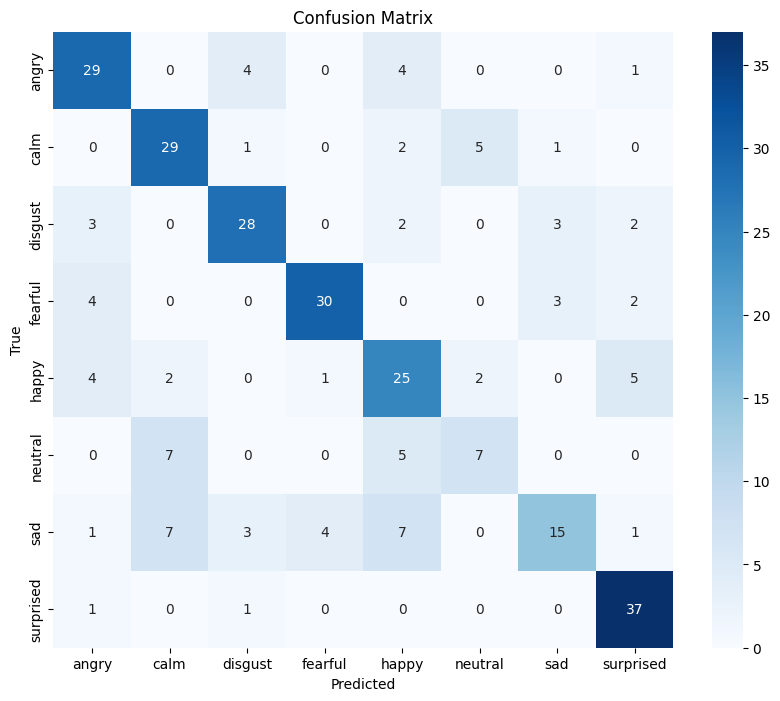

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_names = le.classes_  # Ensure this matches your label encoder
class_report = classification_report(true_labels, predicted_labels, target_names=class_names)
print("Classification Report:")
print(class_report)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()